In [1]:
pip install yfinance plotly dash --user

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import yfinance as yf
import pandas as pd
import numpy as np
import sqlite3

# Fix path - go up to risk_dashboard folder
os.chdir(os.path.dirname(os.path.abspath("__file__")) + "/..")
print("Working directory:", os.getcwd())

Working directory: C:\Users\user\Desktop\risk_dashboard


In [3]:
TICKERS = [
    "JPM", "GS", "HLI",        # Financials
    "AAPL", "PLTR", "META",     # Tech
    "JNJ", "MRK", "UNH",       # Healthcare
    "MCD", "KO",                # Consumer Staples
    "EL", "ULTA",               # Beauty
    "XOM", "CVX"                # Energy
]

In [4]:
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
print("Folders ready!")

Folders ready!


In [5]:
print("Downloading data...")
df = yf.download(TICKERS, start="2022-01-01", end="2025-01-01")["Close"]
df.dropna(how="all", inplace=True)
df.ffill(inplace=True)
df.to_csv("data/raw/prices.csv")
print(f"Saved {len(df)} rows to data/raw/prices.csv")
df.head()

[*********************100%***********************]  15 of 15 completed

Saved 753 rows to data/raw/prices.csv


Ticker,AAPL,CVX,EL,GS,HLI,JNJ,JPM,KO,MCD,META,MRK,PLTR,ULTA,UNH,XOM
Date,,,,,,,,,,,,,,,
2022-01-03,177.939713,99.587158,344.612549,353.786499,96.303482,150.902191,144.191574,51.932373,242.083038,335.592987,66.987167,18.530001,413.230011,463.212494,54.391068
2022-01-04,175.681412,101.399208,346.073608,364.659698,100.689705,150.497543,149.657806,52.799377,242.019974,333.600464,67.109161,18.170000,418.739990,452.717621,56.436932
2022-01-05,171.008286,102.058907,331.415863,356.739746,96.681297,151.500412,146.921783,53.237255,240.830215,321.348053,68.738747,16.959999,401.489990,451.601807,57.138859
2022-01-06,168.153595,102.927345,330.745697,355.218323,101.472954,150.981354,148.482681,52.957016,243.083572,329.565857,68.695168,16.740000,400.489990,433.120605,58.482811
2022-01-07,168.319748,104.405350,330.317688,355.737366,102.578743,153.022247,149.953888,52.834404,240.713043,328.901733,69.976181,16.559999,397.100006,422.929993,58.962162


In [6]:
returns = np.log(df / df.shift(1)).dropna()
returns.to_csv("data/processed/returns_clean.csv")
print(f"Saved returns to data/processed/returns_clean.csv")
returns.head()

Saved returns to data/processed/returns_clean.csv


Ticker,AAPL,CVX,EL,GS,HLI,JNJ,JPM,KO,MCD,META,MRK,PLTR,ULTA,UNH,XOM
Date,,,,,,,,,,,,,,,
2022-01-04,-0.012773,0.018032,0.004231,0.030271,0.044539,-0.002685,0.037209,0.016557,-0.000261,-0.005955,0.001819,-0.019619,0.013246,-0.022917,0.036924
2022-01-05,-0.026960,0.006485,-0.043278,-0.021958,-0.040624,0.006642,-0.018451,0.008259,-0.004928,-0.037419,0.023992,-0.068914,-0.042068,-0.002468,0.012361
2022-01-06,-0.016834,0.008473,-0.002024,-0.004274,0.048372,-0.003432,0.010568,-0.005278,0.009313,0.025251,-0.000634,-0.013057,-0.002494,-0.041785,0.023248
2022-01-07,0.000988,0.014258,-0.001295,0.001460,0.010838,0.013427,0.009860,-0.002318,-0.009800,-0.002017,0.018476,-0.010811,-0.008501,-0.023810,0.008163
2022-01-10,0.000116,0.000640,-0.055137,0.004167,0.036082,-0.004956,0.000957,0.001656,-0.009973,-0.011275,0.025452,-0.003630,-0.041284,0.013859,-0.005970


In [7]:
conn = sqlite3.connect("data/risk_data.db")
df.to_sql("prices", conn, if_exists="replace")
returns.to_sql("returns", conn, if_exists="replace")
conn.close()
print("Saved to data/risk_data.db")
print("\nData pipeline complete!")
print(f"Stocks: {len(df.columns)}")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
print(f"Total trading days: {len(df)}")

Saved to data/risk_data.db

Data pipeline complete!
Stocks: 15
Date range: 2022-01-03 to 2024-12-31
Total trading days: 753


Ticker
AAPL    0
CVX     0
EL      0
GS      0
HLI     0
JNJ     0
JPM     0
KO      0
MCD     0
META    0
MRK     0
PLTR    0
ULTA    0
UNH     0
XOM     0
dtype: int64
(753, 15)
Ticker        AAPL         CVX          EL          GS         HLI  \
count   753.000000  753.000000  753.000000  753.000000  753.000000   
mean    175.865982  138.999890  176.188612  355.645405  106.295897   
std      29.453651   10.460899   65.194863   80.111238   28.980924   
min     122.933540   99.587158   60.933361  253.406433   69.859436   
25%     153.263657  134.417496  124.731766  300.575409   84.074318   
50%     171.030350  140.008728  178.004242  321.410217   96.156044   
75%     189.415924  146.091461  233.495529  386.455200  123.972382   
max     257.375580  162.461319  346.073608  587.761353  185.820267   

Ticker         JNJ         JPM          KO         MCD        META  \
count   753.000000  753.000000  753.000000  753.000000  753.000000   
mean    149.116363  149.637675   56.591747  253.3

<Axes: title={'center': 'Stock Prices 2022-2025'}, xlabel='Date'>

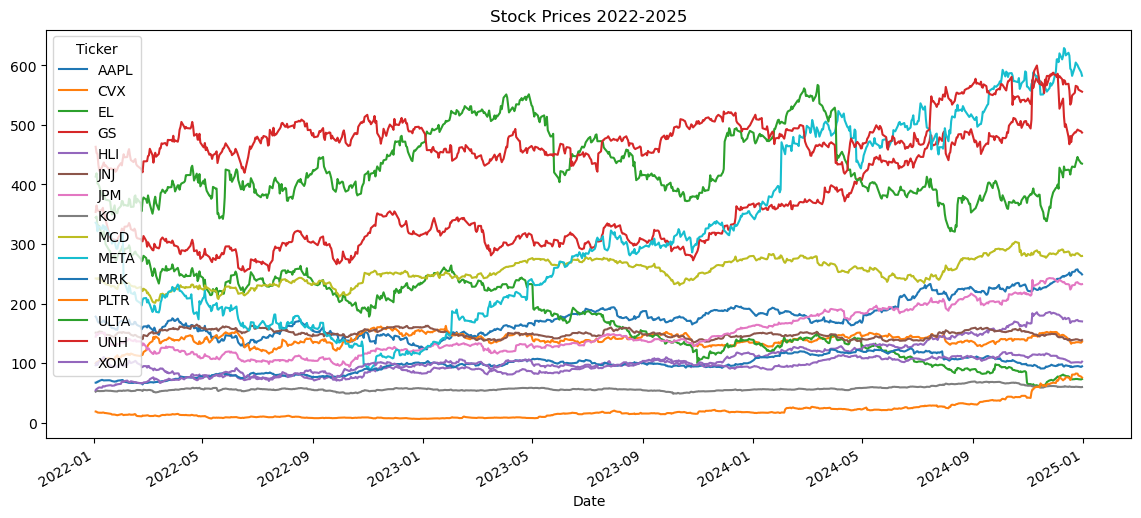

In [8]:
# Check missing values
print(df.isnull().sum())

# Check shape
print(df.shape)

# Basic statistics
print(df.describe())

# Plot prices
df.plot(figsize=(14,6), title="Stock Prices 2022-2025")

In [9]:
import os
print(os.listdir("data/processed/"))

['returns_clean.csv']
